# DBSCAN: Density-Based Clustering

## Overview

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups observations that are closely packed and labels isolated observations as noise (cluster 0). Unlike k-means, it discovers the number of clusters automatically, handles non-convex shapes, and explicitly models outliers.

**Core concepts:**
- **Core point:** has ≥ `minPts` neighbours within radius `eps`
- **Border point:** within `eps` of a core point but fewer than `minPts` neighbours itself
- **Noise point:** not a core point or border point — labelled cluster 0

**Parameters:**

| Parameter | Controls | How to choose |
|---|---|---|
| `eps` | Neighbourhood radius | k-NN distance plot: find the "knee" |
| `minPts` | Minimum neighbours for a core point | Rule of thumb: ≥ dimensionality + 1; typically 5–20 |

**When to use DBSCAN over k-means:**
- Clusters are non-convex (elongated, ring-shaped, irregular)
- Number of clusters is unknown
- Outliers/noise are expected and should be identified
- Clusters have very different sizes or densities

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(dbscan)        # dbscan(), hdbscan(), kNNdistplot()
library(factoextra)
library(patchwork)

set.seed(42)

# ── Dataset 1: rings (defeats k-means completely) ─────────────────────────────
n <- 300
theta_inner <- runif(n/3, 0, 2*pi)
theta_outer <- runif(n*2/3, 0, 2*pi)
ring_data <- tibble(
  x = c(cos(theta_inner)*2 + rnorm(n/3,0,0.15),
         cos(theta_outer)*5 + rnorm(n*2/3,0,0.25)),
  y = c(sin(theta_inner)*2 + rnorm(n/3,0,0.15),
         sin(theta_outer)*5 + rnorm(n*2/3,0,0.25))
) %>%
  bind_rows(tibble(x=runif(15,-7,7), y=runif(15,-7,7)))  # add noise

# ── Dataset 2: ecological sites with outlier contamination ───────────────────
n_per <- 80
eco_data <- bind_rows(
  tibble(nitrate=rnorm(n_per,2,0.5), water_qual=rnorm(n_per,8,0.7)),
  tibble(nitrate=rnorm(n_per,6,0.6), water_qual=rnorm(n_per,5,0.8)),
  tibble(nitrate=rnorm(n_per,10,0.7), water_qual=rnorm(n_per,2,0.6)),
  # Outliers / contaminated sites
  tibble(nitrate=c(15,1,12), water_qual=c(9,0.5,0.3))
) %>%
  mutate(across(everything(), scale))

Warning message:
"package 'dbscan' was built under R version 4.4.3"



Attaching package: 'dbscan'


The following object is masked from 'package:stats':

    as.dendrogram


Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

Warning message:
"package 'patchwork' was built under R version 4.4.3"


---

## Choosing eps: k-NN Distance Plot

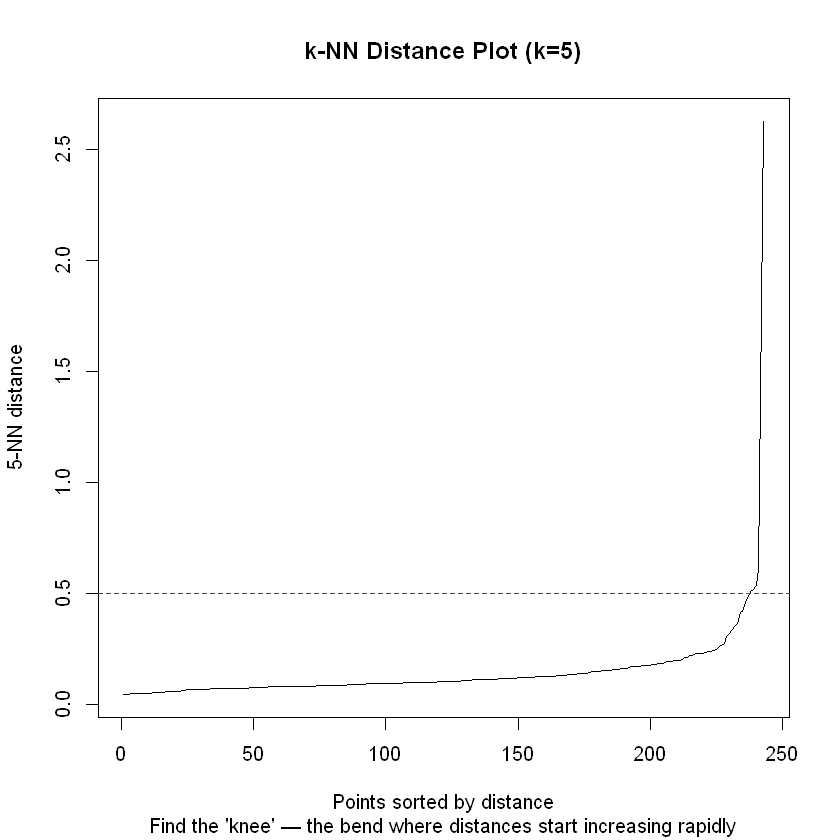

In [4]:
# The k-NN distance plot shows the distance to the k-th nearest neighbour,
# sorted in ascending order. The 'knee' in this curve is a good eps estimate.
# Use k = minPts (same value you plan to use in DBSCAN)

minPts_val <- 5

dbscan::kNNdistplot(eco_data, k=minPts_val)
abline(h=0.5, lty=2, col="red")   # candidate eps
title(main="k-NN Distance Plot (k=5)",
      sub="Find the 'knee' — the bend where distances start increasing rapidly")
# The knee indicates the transition from within-cluster to between-cluster distances
# Points above the knee are likely noise at the chosen eps

---

## Fit DBSCAN

DBSCAN on ecological data:
  Clusters found: 2
  Noise points:   2

  0   1   2 
  2  81 160 


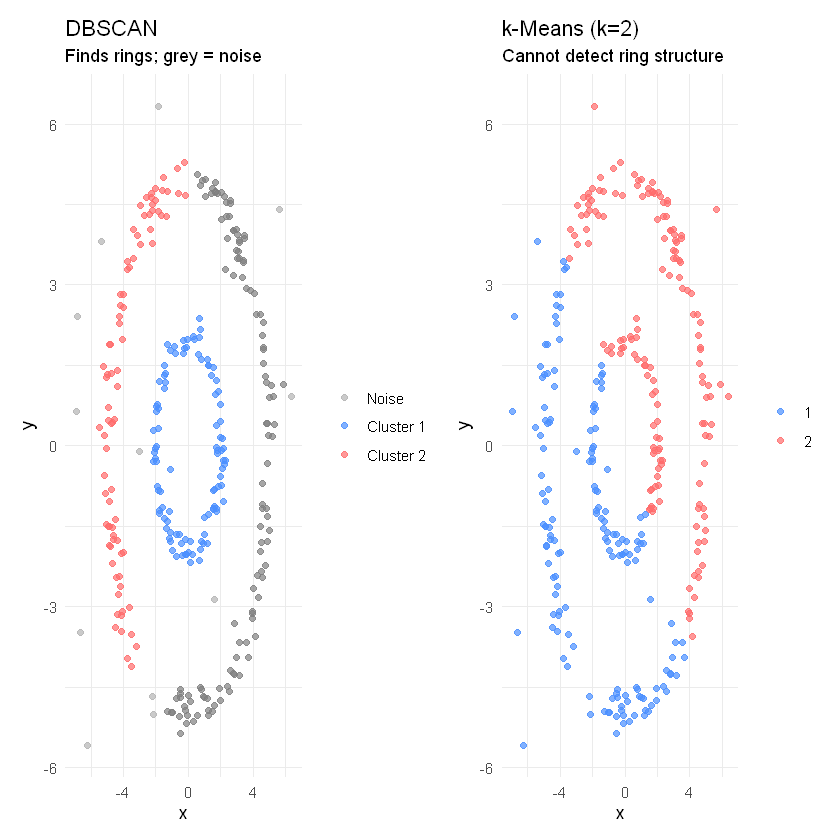

In [5]:
# ── Ring data: DBSCAN vs. k-means ─────────────────────────────────────────────
ring_scaled <- scale(ring_data)

db_rings <- dbscan::dbscan(ring_scaled, eps=0.25, minPts=5)
km_rings <- kmeans(ring_scaled, centers=2, nstart=25)

p_db <- ring_data %>%
  mutate(cluster=factor(db_rings$cluster)) %>%
  ggplot(aes(x=x, y=y, color=cluster)) +
  geom_point(alpha=0.7, size=1.5) +
  scale_color_manual(
    values=c("0"="gray70","1"="#4a8fff","2"="#ff6b6b"),
    labels=c("0"="Noise","1"="Cluster 1","2"="Cluster 2")
  ) +
  labs(title="DBSCAN", subtitle="Finds rings; grey = noise",
       color=NULL) + theme_minimal()

p_km <- ring_data %>%
  mutate(cluster=factor(km_rings$cluster)) %>%
  ggplot(aes(x=x, y=y, color=cluster)) +
  geom_point(alpha=0.7, size=1.5) +
  scale_color_manual(values=c("#4a8fff","#ff6b6b")) +
  labs(title="k-Means (k=2)", subtitle="Cannot detect ring structure",
       color=NULL) + theme_minimal()

(p_db | p_km)

# ── Ecological data: detecting outliers ───────────────────────────────────────
db_eco <- dbscan::dbscan(eco_data, eps=0.5, minPts=minPts_val)
cat(sprintf("DBSCAN on ecological data:\n"))
cat(sprintf("  Clusters found: %d\n", max(db_eco$cluster)))
cat(sprintf("  Noise points:   %d\n", sum(db_eco$cluster==0)))
print(table(db_eco$cluster))

---

## HDBSCAN: Hierarchical DBSCAN

HDBSCAN clusters: 3 | Noise: 4

Membership probability summary:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.6494  0.7846  0.7070  0.8395  0.9327 

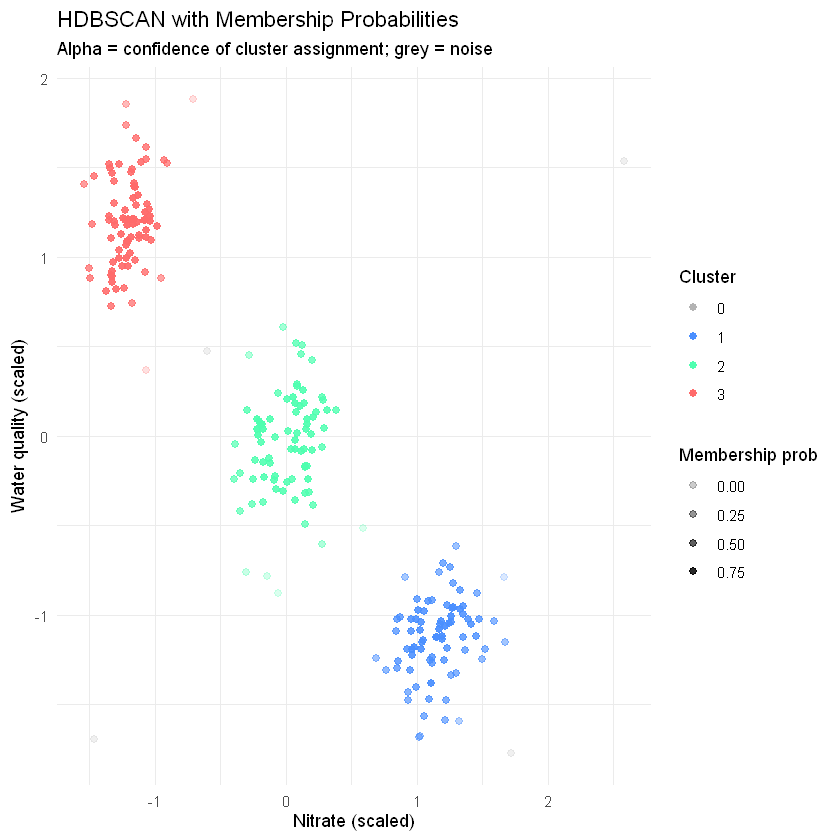

In [6]:
# HDBSCAN: hierarchical variant that handles variable-density clusters
# Does not require eps — only minPts is needed
# Extracts flat clustering from the cluster hierarchy

hdb <- dbscan::hdbscan(eco_data, minPts=5)
cat(sprintf("HDBSCAN clusters: %d | Noise: %d\n",
            max(hdb$cluster), sum(hdb$cluster==0)))

# Membership probabilities: how confident is the assignment?
cat("\nMembership probability summary:\n")
summary(hdb$membership_prob)

# Plot
as_tibble(eco_data) %>%
  mutate(
    cluster = factor(hdb$cluster),
    prob    = hdb$membership_prob
  ) %>%
  ggplot(aes(x=nitrate, y=water_qual, color=cluster, alpha=prob)) +
  geom_point(size=2) +
  scale_color_manual(values=c("0"="gray70","1"="#4a8fff",
                               "2"="#4fffb0","3"="#ff6b6b")) +
  scale_alpha_continuous(range=c(0.2, 1)) +
  labs(title="HDBSCAN with Membership Probabilities",
       subtitle="Alpha = confidence of cluster assignment; grey = noise",
       x="Nitrate (scaled)", y="Water quality (scaled)",
       color="Cluster", alpha="Membership prob") +
  theme_minimal()

---

## Common Pitfalls

**1. Choosing eps arbitrarily without the k-NN distance plot**  
eps is highly sensitive — a value too small produces many noise points and fragmented clusters; too large merges everything into one cluster. Always use `kNNdistplot()` to find the knee in the k-th nearest-neighbour distance curve before fitting.

**2. Not scaling features before DBSCAN**  
Like k-means, DBSCAN uses Euclidean distance. Unscaled features with different ranges will cause the algorithm to find structure only in the high-variance features. Always scale to unit variance before applying DBSCAN.

**3. Treating noise points (cluster 0) as a cluster**  
Noise points are observations that do not belong to any dense region — they are outliers or points between clusters. They should be examined individually, not treated as a homogeneous group. Reporting "4 clusters including noise" misrepresents the result.

**4. Using DBSCAN when cluster densities vary greatly**  
A single eps cannot capture clusters of very different densities. If one cluster has 10× the density of another, the optimal eps for the dense cluster will absorb sparse-cluster points as noise. Use HDBSCAN for variable-density data — it adapts the density threshold hierarchically.

**5. Interpreting DBSCAN results as definitive cluster assignments**  
Border points are assigned to whichever cluster's core point found them first — this is algorithm-dependent and can vary with data ordering or eps. Core points have deterministic assignments; border point assignments are not. Treat border points with lower confidence.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*